# Indice de Convergence Technologique — v6 + Analyse Prédictive

## Ce notebook fait deux choses

### PARTIE 1 — Version 6 de l'indice
Correction du dernier problème structurel identifié en v5 :
C3_delta pénalisait les convergences matures (ΔJaccard < 0 après fusion consommée).
**Correction v6 : C3 = max(ΔJaccard_lissé, 0)** — on ne prend en compte que
les accélérations positives, on ignore les décélérations.
Une paire mature ne doit pas être pénalisée pour avoir stabilisé sa convergence.

### PARTIE 2 — Ce que l'indice nous dit vraiment
L'indice CI_A (MODE A, rank par année) répond à la question :
**« Quelles paires de technologies convergent anormalement vite en ce moment ? »**

C'est une question prédictive : une paire avec CI_A élevé aujourd'hui est
candidate à former un nouveau domaine technologique dans 5-10 ans.

Nous exploitons cela avec trois analyses :

**Analyse 1 — Émergences détectées avant qu'elles soient connues**
Validation rétroactive : est-ce que l'indice détectait en 2005 les
convergences qui ont abouti à des marchés réels après 2015 ?

**Analyse 2 — Les convergences en cours (2018-2022)**
Quelles sont les paires qui convergent le plus fortement sur les
dernières années ? Ce sont les candidats aux marchés de demain.

**Analyse 3 — Cartographie des domaines d'émergence**
Quels codes CPC sont impliqués dans le plus de convergences actives ?
Ce sont les technologies pivot de la prochaine vague d'innovation.

In [1]:
import pandas as pd
import numpy as np
import itertools
from collections import Counter, defaultdict
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

# ════════════════════════════════════════════════════════════════
# PARAMÈTRES
# ════════════════════════════════════════════════════════════════
WINDOW           = 5
K_CLUSTERS       = 10
N_PCA_CLUST      = 20
YEAR_START       = 1980
YEAR_END         = 2022
MIN_PATENTS      = 30
MIN_COOC         = 20
DELTA_SMOOTH     = 3
MIN_YEARS_CYLINDRE = 30

# ── Poids v6 (C3 = max(ΔJaccard, 0)) ────────────────────────────
# C3 ne peut plus être négatif → pénalisation des convergences
# matures supprimée. Le poids de C3 reste à 0.30 car c'est la
# dimension dynamique la plus informative.
W = {'C1_jaccard': 0.55, 'C3_delta': 0.30, 'C4_cluster': 0.15}

---
# PARTIE 1 — Version 6 de l'indice

In [2]:
# ── Chargement ───────────────────────────────────────────────────
df_raw = pd.read_parquet("multi_codes_brevets.parquet")
df_raw = df_raw.dropna(subset=["year", "cpc4_list"]).copy()
df_raw["year"] = df_raw["year"].astype(int)

def normalize_cpc_list(lst):
    clean = []
    for c in lst:
        if c is None: continue
        s = str(c).upper().strip()
        if len(s) >= 3: clean.append(s[:4])
    return sorted(set(clean))

df_raw["cpc4"] = df_raw["cpc4_list"].apply(normalize_cpc_list)
df_raw = df_raw[df_raw["cpc4"].apply(len) >= 2].copy()
brevet_count_by_year = df_raw.groupby("year").size().to_dict()
N_mean = np.mean(list(brevet_count_by_year.values()))
print(f"Brevets : {len(df_raw):,}")

Brevets : 1,234,382


In [3]:
# ── Jaccard + filtres (identique v5) ─────────────────────────────
def compute_jaccard_yearly(df, window=WINDOW, min_patents=MIN_PATENTS):
    years = sorted(df["year"].unique())
    records = []
    for t in years:
        df_w = df[(df["year"] >= t-window//2) & (df["year"] <= t+window//2)]
        n_i = Counter(); n_ij = Counter()
        for _, row in df_w.iterrows():
            codes = row["cpc4"]
            for c in codes: n_i[c] += 1
            for ci, cj in itertools.combinations(codes, 2):
                n_ij[(min(ci,cj), max(ci,cj))] += 1
        for (ci,cj), cnt in n_ij.items():
            ni, nj = n_i[ci], n_i[cj]
            if ni < min_patents or nj < min_patents: continue
            union = ni + nj - cnt
            records.append({
                "cpc_i":ci, "cpc_j":cj, "year":t,
                "jaccard": cnt/union if union>0 else 0,
                "p_j_given_i": cnt/ni, "p_i_given_j": cnt/nj,
                "n_cooc": cnt
            })
    return pd.DataFrame(records)

print("Calcul Jaccard...")
df_jac = compute_jaccard_yearly(df_raw)
df_jac = df_jac[df_jac["n_cooc"] >= MIN_COOC].copy()
df_jac["px_i"] = df_jac["cpc_i"].str[:3]
df_jac["px_j"] = df_jac["cpc_j"].str[:3]
df_jac = df_jac[df_jac["px_i"] != df_jac["px_j"]].drop(columns=["px_i","px_j"]).copy()
print(f"  {len(df_jac):,} obs. après filtres")

Calcul Jaccard...
  165,484 obs. après filtres


Calcul ΔJaccard v6...
  ΔJaccard > 0 : 66,455
  ΔJaccard = 0 : 99,029 (stables ou décélérant)


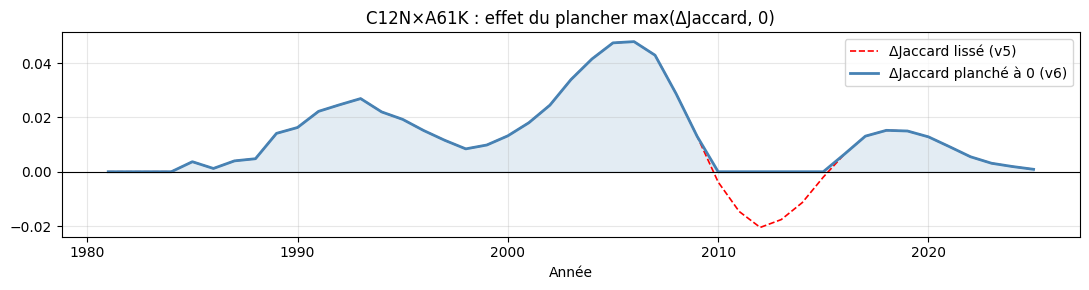

In [4]:
# ── ΔJaccard lissé avec plancher à 0 (CORRECTION V6) ─────────────
def compute_delta_jaccard_v6(df_jac, window=WINDOW, smooth=DELTA_SMOOTH):
    """
    ΔJaccard lissé avec plancher à 0.

    CORRECTION V6 : C3 = max(ΔJaccard_lissé, 0)

    Justification : en v5, ΔJaccard < 0 pénalisait les paires dont
    la convergence est consommée (Jaccard se stabilise après fusion).
    Exemple : C12N×A61K après 2008 avait ΔJaccard < 0 car la
    biopharmacie est devenue un domaine intégré — sa centralité
    n'augmente plus mais elle n'a pas divergé.
    En imposant max(ΔJaccard, 0), on mesure uniquement l'accélération
    positive, sans pénaliser les convergences matures.
    """
    df = df_jac.copy().sort_values(["cpc_i","cpc_j","year"])
    df_lag = df[["cpc_i","cpc_j","year","jaccard"]].copy()
    df_lag["year_future"] = df_lag["year"] + window
    df_lag = df_lag.rename(columns={"jaccard":"jaccard_lag","year":"year_lag"})
    df = df.merge(
        df_lag[["cpc_i","cpc_j","year_future","jaccard_lag"]],
        left_on=["cpc_i","cpc_j","year"],
        right_on=["cpc_i","cpc_j","year_future"], how="left"
    ).drop(columns=["year_future"])
    df["delta_raw"] = (df["jaccard"] - df["jaccard_lag"]).fillna(0)

    # lissage
    df = df.sort_values(["cpc_i","cpc_j","year"])
    df["delta_smooth"] = (
        df.groupby(["cpc_i","cpc_j"])["delta_raw"]
        .transform(lambda s: s.rolling(smooth, center=True, min_periods=2).mean())
        .fillna(df["delta_raw"])
    )

    # ── CORRECTION V6 : plancher à 0 ────────────────────────────
    df["delta_jaccard"] = df["delta_smooth"].clip(lower=0)

    return df


print("Calcul ΔJaccard v6...")
df_jac = compute_delta_jaccard_v6(df_jac)
print(f"  ΔJaccard > 0 : {(df_jac['delta_jaccard']>0).sum():,}")
print(f"  ΔJaccard = 0 : {(df_jac['delta_jaccard']==0).sum():,} (stables ou décélérant)")

# vérification sur C12N×A61K
mask = ((df_jac["cpc_i"]=="C12N")&(df_jac["cpc_j"]=="A61K")) | \
       ((df_jac["cpc_i"]=="A61K")&(df_jac["cpc_j"]=="C12N"))
sub = df_jac[mask].sort_values("year")
if len(sub) > 0:
    fig, ax = plt.subplots(figsize=(11,3))
    ax.plot(sub["year"], sub["delta_smooth"], color="red", lw=1.2, ls="--", label="ΔJaccard lissé (v5)")
    ax.plot(sub["year"], sub["delta_jaccard"], color="steelblue", lw=2, label="ΔJaccard planché à 0 (v6)")
    ax.fill_between(sub["year"], 0, sub["delta_jaccard"], alpha=0.15, color="steelblue")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title("C12N×A61K : effet du plancher max(ΔJaccard, 0)")
    ax.set_xlabel("Année")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [5]:
# ── C4 clustering (identique v5) ─────────────────────────────────
def build_cooc_matrix(df, y0, y1):
    df_w = df[(df["year"]>=y0)&(df["year"]<=y1)]
    df_w = df_w[df_w["cpc4"].apply(lambda x: len(x)>=2)]
    pc = Counter()
    for cpcs in df_w["cpc4"]:
        for ci,cj in itertools.combinations(sorted(set(cpcs)),2):
            pc[(ci,cj)]+=1; pc[(cj,ci)]+=1
    cooc = pd.DataFrame([(i,j,c) for (i,j),c in pc.items()],columns=["cpc_i","cpc_j","count"])
    rs = cooc.groupby("cpc_i")["count"].sum().rename("row_sum")
    cooc = cooc.join(rs,on="cpc_i")
    cooc["M_ij"] = cooc["count"]/cooc["row_sum"]
    return cooc

print("Clustering...")
pca_c = PCA(n_components=N_PCA_CLUST,random_state=0)
km    = KMeans(n_clusters=K_CLUSTERS,random_state=0,n_init=10)
ct = []
for s in range(YEAR_START, YEAR_END-WINDOW+2):
    e = s+WINDOW-1
    cw = build_cooc_matrix(df_raw,s,e)
    if len(cw)==0: continue
    M = cw.pivot(index="cpc_i",columns="cpc_j",values="M_ij").fillna(0)
    if M.shape[0]<N_PCA_CLUST: continue
    cl = km.fit_predict(pca_c.fit_transform(M))
    ct.append(pd.DataFrame({"cpc":M.index,"cluster":cl,"year":s+WINDOW//2}))
ctdf = pd.concat(ct,ignore_index=True)

def entropy_fn(p):
    p=p[p>0]; return -np.sum(p*np.log(p))

tr=[]
for cpc,sub in ctdf.sort_values(["cpc","year"]).groupby("cpc"):
    sub=sub.sort_values("year")
    for i in range(len(sub)-1):
        tr.append({"cpc":cpc,"year_t":sub.iloc[i]["year"],"year_t1":sub.iloc[i+1]["year"],
                   "cluster_t":sub.iloc[i]["cluster"],"cluster_t1":sub.iloc[i+1]["cluster"]})
tdf=pd.DataFrame(tr)
infl=tdf.groupby(["year_t1","cluster_t1"])["cluster_t"].value_counts(normalize=True).rename("p").reset_index()
infH=infl.groupby(["year_t1","cluster_t1"])["p"].apply(entropy_fn).reset_index(name="H_in")
per=tdf.groupby(["year_t","cluster_t"]).apply(lambda x:np.mean(x["cluster_t1"]==x["cluster_t"])).reset_index(name="persistence")
adf=infH.merge(per,left_on=["year_t1","cluster_t1"],right_on=["year_t","cluster_t"],how="left").drop(columns=["year_t","cluster_t"])
adf=adf.rename(columns={"year_t1":"year","cluster_t1":"cluster"})
adf["absorption_score"]=adf["H_in"]*adf["persistence"].fillna(0)
adf["is_abs"]=(adf["H_in"]>=adf["H_in"].quantile(0.75))&(adf["persistence"]>=adf["persistence"].quantile(0.75))

cl_lkp=ctdf.set_index(["cpc","year"])["cluster"].to_dict()
ab_lkp=adf.set_index(["year","cluster"])["absorption_score"].to_dict()
df_c4=df_jac[["cpc_i","cpc_j","year"]].copy()
def rc4(r):
    ci=cl_lkp.get((r["cpc_i"],r["year"])); cj=cl_lkp.get((r["cpc_j"],r["year"]))
    if ci is None or cj is None or ci!=cj: return 0.0
    return ab_lkp.get((r["year"],ci),0.0)
df_c4["cluster_absorption"]=df_c4.apply(rc4,axis=1)
print(f"  {(df_c4['cluster_absorption']>0).sum():,} paires absorbantes")

Clustering...
  24,480 paires absorbantes


In [6]:
# ── Assemblage panel + normalisation MODE A ───────────────────────
keys=["cpc_i","cpc_j","year"]
panel=(
    df_jac[["cpc_i","cpc_j","year","jaccard","delta_jaccard","delta_smooth","delta_raw","jaccard_lag","p_j_given_i","p_i_given_j","n_cooc"]]
    .merge(df_c4,on=keys,how="left")
)
panel["cluster_absorption"]=panel["cluster_absorption"].fillna(0)
panel=panel[panel["year"]<=YEAR_END].copy()

# rank par année
def rby(df,col): return df.groupby("year")[col].rank(method="average",pct=True)
panel["C1_A"]=rby(panel,"jaccard")
panel["C3_A"]=rby(panel,"delta_jaccard")  # v6 : delta_jaccard est déjà ≥ 0
panel["C4_A"]=0.0
mask_abs=panel["cluster_absorption"]>0
if mask_abs.sum()>0:
    panel.loc[mask_abs,"C4_A"]=(
        panel[mask_abs].groupby("year")["cluster_absorption"]
        .rank(method="average",pct=True)
    )
panel["CI_v6"]=W["C1_jaccard"]*panel["C1_A"]+W["C3_delta"]*panel["C3_A"]+W["C4_cluster"]*panel["C4_A"]
panel["CI_v6"]=(panel["CI_v6"]-panel["CI_v6"].min())/(panel["CI_v6"].max()-panel["CI_v6"].min())

print(f"Panel : {len(panel):,} lignes | {panel['year'].nunique()} années")
print(f"CI_v6 : mean={panel['CI_v6'].mean():.4f}, std={panel['CI_v6'].std():.4f}")

Panel : 145,843 lignes | 43 années
CI_v6 : mean=0.3935, std=0.2205


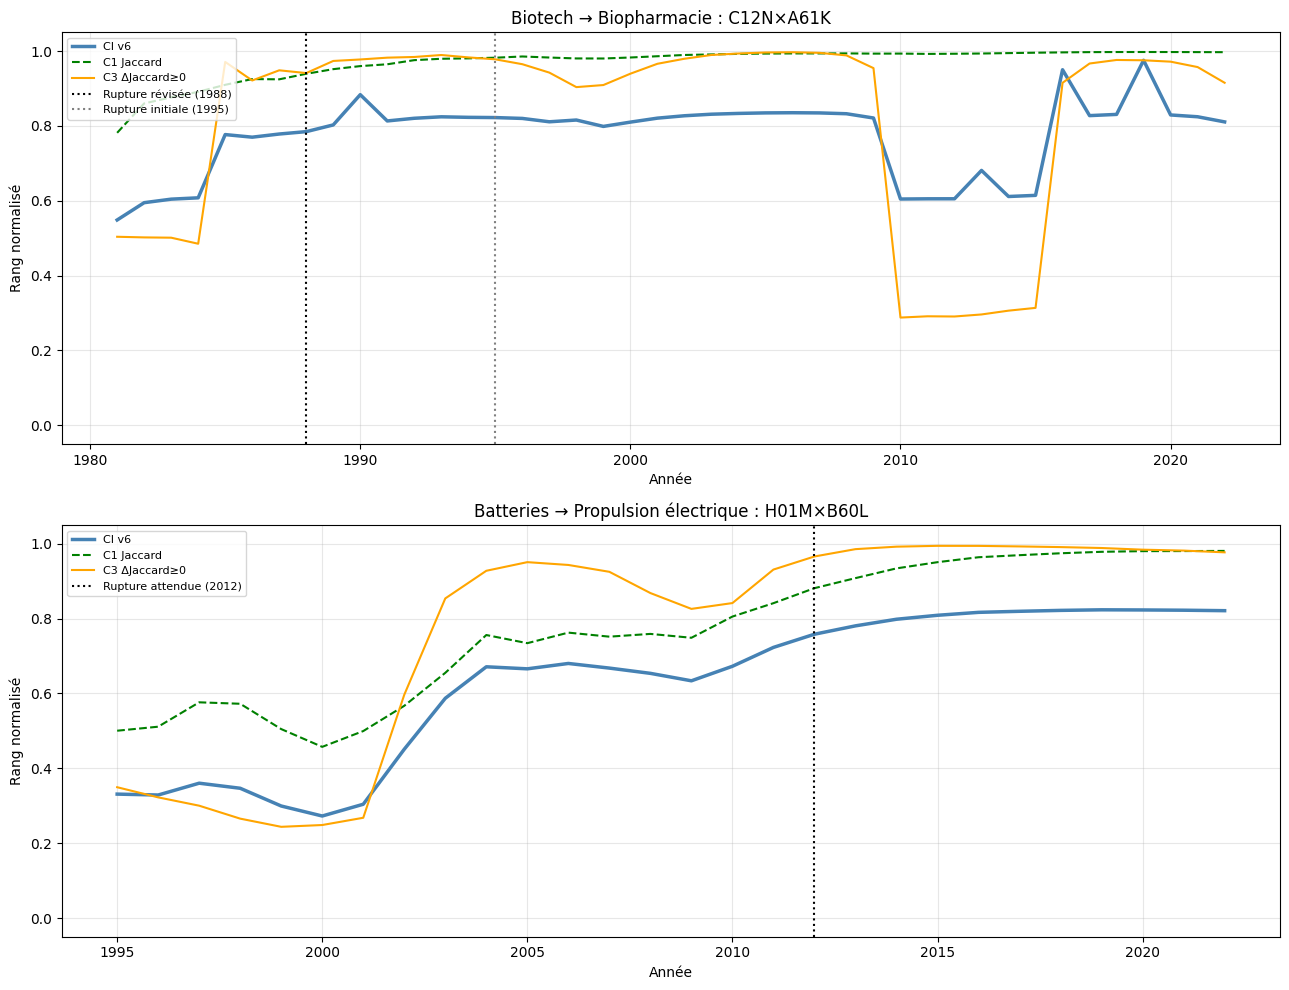

In [7]:
# ── Validation ground truth v6 ───────────────────────────────────
def plot_gt(panel, ci, cj, label, breaks, ax=None):
    mask=((panel["cpc_i"]==ci)&(panel["cpc_j"]==cj))|((panel["cpc_i"]==cj)&(panel["cpc_j"]==ci))
    sub=panel[mask].sort_values("year")
    if len(sub)==0: print(f"⚠ {ci}×{cj} absente"); return
    if ax is None: _,ax=plt.subplots(figsize=(12,4))
    ax.plot(sub["year"],sub["CI_v6"], lw=2.5,color="steelblue",label="CI v6")
    ax.plot(sub["year"],sub["C1_A"],  lw=1.5,color="green", ls="--",label="C1 Jaccard")
    ax.plot(sub["year"],sub["C3_A"],  lw=1.5,color="orange",label="C3 ΔJaccard≥0")
    for yr,lbl,col in breaks:
        ax.axvline(yr,color=col,ls=":",lw=1.5,label=lbl)
    ax.set_title(f"{label} : {ci}×{cj}")
    ax.set_xlabel("Année"); ax.set_ylabel("Rang normalisé")
    ax.legend(fontsize=8,loc="upper left"); ax.grid(alpha=0.3); ax.set_ylim(-0.05,1.05)

fig,axes=plt.subplots(2,1,figsize=(13,10))
plot_gt(panel,"C12N","A61K","Biotech → Biopharmacie",
        [(1988,"Rupture révisée (1988)","black"),(1995,"Rupture initiale (1995)","gray")],ax=axes[0])
plot_gt(panel,"H01M","B60L","Batteries → Propulsion électrique",
        [(2012,"Rupture attendue (2012)","black")],ax=axes[1])
plt.tight_layout()
plt.savefig("validation_v6.png",dpi=150,bbox_inches="tight")
plt.show()

---
# PARTIE 2 — Ce que l'indice nous dit vraiment

## Interprétation économique de CI_v6

CI_v6(i,j,t) mesure le **rang relatif de convergence** de la paire (i,j)
parmi toutes les paires actives à l'année t.

Une paire avec CI_v6 = 0.95 en 2020 signifie :
- Elle est dans le top 5% des convergences les plus actives cette année
- Son Jaccard est élevé (C1) ET croissant (C3)
- Elle est éventuellement dans un cluster absorbant (C4)

**Hypothèse prédictive** (issue de la littérature sur les réseaux d'innovation) :
Une convergence soutenue sur 5-10 ans précède généralement l'émergence
d'un nouveau marché ou d'une nouvelle discipline technologique.
(Acemoglu et al. 2016, Erdi et al. 2013)

## Analyse 1 — Validation rétroactive : l'indice détectait-il les émergences futures ?

In [8]:
# Dictionnaire de significations CPC4 (principales)
CPC_LABELS = {
    "G06F":"Informatique","G06N":"IA/Réseaux neuronaux","G06T":"Traitement image",
    "G06Q":"Commerce/Gestion","H04L":"Transmission données","H04W":"Réseaux mobiles",
    "H04N":"Vidéo/Imagerie","H01L":"Semi-conducteurs","H01M":"Batteries/Piles",
    "B60L":"Propulsion électrique","B60W":"Contrôle véhicule","B60K":"Transmission véhicule",
    "A61K":"Préparations pharma","A61P":"Activité thérapeutique","A61B":"Diagnostic médical",
    "C12N":"Biologie moléculaire","C12Q":"Mesure biologiques","G01N":"Analyse matériaux",
    "G01S":"Radar/LIDAR","G05B":"Contrôle/Automatisation","B25J":"Robotique",
    "H02M":"Conversion énergie","H02J":"Distribution énergie",
    "F03D":"Éoliennes","H02S":"Solaire photovoltaïque",
    "G16H":"Informatique médicale","A61C":"Dentisterie",
    "B33Y":"Impression 3D","B22F":"Métallurgie poudres",
    "C09K":"Matériaux spéciaux","H10K":"Électronique organique",
}

def label_pair(ci, cj):
    li = CPC_LABELS.get(ci, ci)
    lj = CPC_LABELS.get(cj, cj)
    return f"{ci} ({li}) × {cj} ({lj})"


# Paires connues qui ont émergé comme marchés réels après 2010
# → on vérifie si l'indice les détectait en 2000-2005
KNOWN_EMERGENCES = [
    ("H01M", "B60L", "Véhicule électrique",      2012),
    ("G06N", "G06F", "Deep Learning/Informatique", 2015),
    ("G01S", "B60W", "LIDAR/Conduite autonome",   2015),
    ("H02S", "H02J", "Solaire/Réseau électrique",  2010),
    ("B33Y", "B22F", "Impression 3D/Métallurgie",  2012),
    ("G16H", "G06N", "IA médicale",                2017),
]

print("═" * 70)
print("VALIDATION RÉTROACTIVE : score CI_v6 en 2005 pour les marchés post-2010")
print("═" * 70)

results_retro = []
for ci, cj, label, year_emerge in KNOWN_EMERGENCES:
    mask = (
        ((panel["cpc_i"]==ci)&(panel["cpc_j"]==cj)) |
        ((panel["cpc_i"]==cj)&(panel["cpc_j"]==ci))
    )
    sub = panel[mask].sort_values("year")
    if len(sub) == 0:
        print(f"  ⚠ {label} : paire absente du panel")
        continue

    # score 5 ans avant l'émergence
    year_signal = year_emerge - 5
    score_avant = sub[sub["year"]==year_signal]["CI_v6"].values
    score_apres = sub[sub["year"]==min(year_emerge+2, YEAR_END)]["CI_v6"].values

    s_av = score_avant[0] if len(score_avant)>0 else np.nan
    s_ap = score_apres[0] if len(score_apres)>0 else np.nan

    results_retro.append({
        "Marché émergent": label,
        "Année émergence": year_emerge,
        f"CI_v6 en {year_signal}": round(s_av, 3) if not np.isnan(s_av) else "N/A",
        f"CI_v6 en {min(year_emerge+2,YEAR_END)}": round(s_ap, 3) if not np.isnan(s_ap) else "N/A",
        "Signal précurseur": "✅ OUI" if (not np.isnan(s_av) and s_av > 0.65) else "❌ NON"
    })

df_retro = pd.DataFrame(results_retro)
display(df_retro)

══════════════════════════════════════════════════════════════════════
VALIDATION RÉTROACTIVE : score CI_v6 en 2005 pour les marchés post-2010
══════════════════════════════════════════════════════════════════════
  ⚠ Deep Learning/Informatique : paire absente du panel
  ⚠ Solaire/Réseau électrique : paire absente du panel


,Marché émergent,Année émergence,CI_v6 en 2007,CI_v6 en 2014,Signal précurseur,CI_v6 en 2010,CI_v6 en 2017,CI_v6 en 2012,CI_v6 en 2019
0,Véhicule électrique,2012,0.668,0.798,✅ OUI,NaN,NaN,NaN,NaN
1,LIDAR/Conduite autonome,2015,NaN,NaN,❌ NON,0.492,0.518,NaN,NaN
2,Impression 3D/Métallurgie,2012,0.724,0.812,✅ OUI,NaN,NaN,NaN,NaN
3,IA médicale,2017,NaN,NaN,❌ NON,NaN,NaN,N/A,0.536


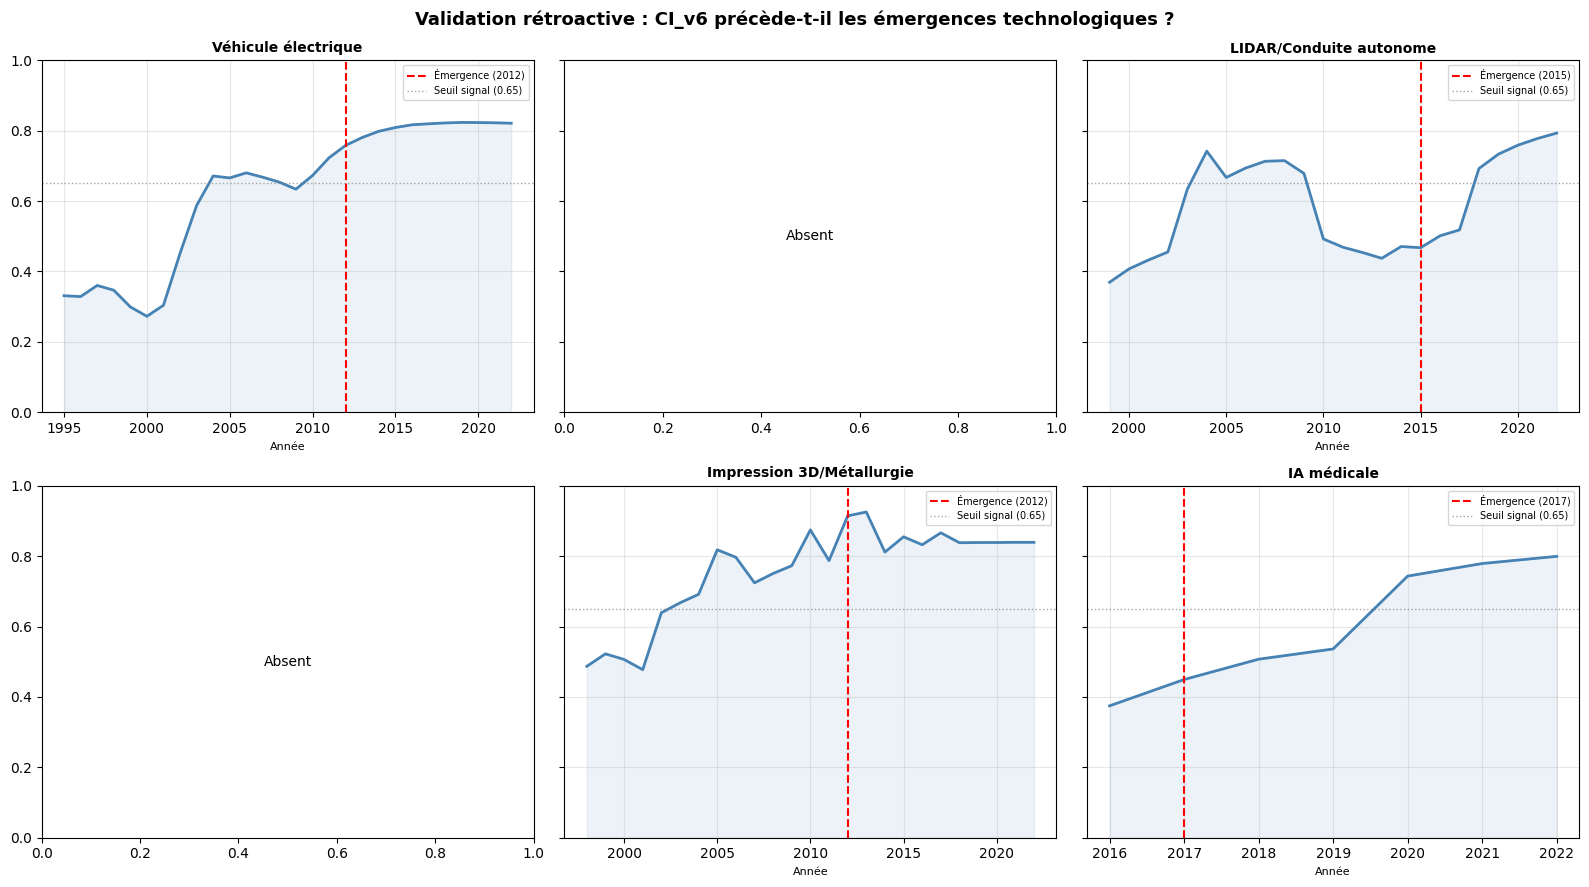

In [9]:
# Visualisation : trajectoires des paires connues
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
axes = axes.flatten()

for idx, (ci, cj, label, year_emerge) in enumerate(KNOWN_EMERGENCES):
    mask = (
        ((panel["cpc_i"]==ci)&(panel["cpc_j"]==cj)) |
        ((panel["cpc_i"]==cj)&(panel["cpc_j"]==ci))
    )
    sub = panel[mask].sort_values("year")
    ax = axes[idx]
    if len(sub) == 0:
        ax.text(0.5, 0.5, "Absent", ha="center", va="center", transform=ax.transAxes)
        continue
    ax.plot(sub["year"], sub["CI_v6"], lw=2, color="steelblue")
    ax.fill_between(sub["year"], 0, sub["CI_v6"], alpha=0.1, color="steelblue")
    ax.axvline(year_emerge, color="red", ls="--", lw=1.5, label=f"Émergence ({year_emerge})")
    ax.axhline(0.65, color="gray", ls=":", lw=1, alpha=0.7, label="Seuil signal (0.65)")
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_xlabel("Année", fontsize=8)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle("Validation rétroactive : CI_v6 précède-t-il les émergences technologiques ?",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("validation_retroactive.png", dpi=150, bbox_inches="tight")
plt.show()

## Analyse 2 — Les convergences en cours (2018-2022) : les marchés de demain

In [11]:
# Score de convergence soutenue sur 2018-2022
# On prend la médiane du CI_v6 sur les 5 dernières années disponibles
# Une paire avec une médiane élevée sur 5 ans est en convergence soutenue
# (pas juste un pic accidentel)

recent = panel[panel["year"] >= 2018].copy()

# score de convergence soutenue = médiane CI_v6 sur 2018-2022
score_recent = (
    recent
    .groupby(["cpc_i","cpc_j"])
    .agg(
        CI_median   = ("CI_v6",    "median"),
        CI_trend    = ("CI_v6",    lambda x: np.polyfit(range(len(x)), x, 1)[0] if len(x)>1 else 0),
        jaccard_last= ("jaccard",  "last"),
        delta_last  = ("delta_jaccard", "last"),
        n_cooc_mean = ("n_cooc",   "mean"),
        n_years     = ("year",     "count")
    )
    .reset_index()
)

# Score composite : médiane élevée ET tendance croissante
trend_pos = score_recent["CI_trend"].clip(lower=0)
trend_max = max(float(trend_pos.max()), 1e-10)
score_recent["score_futur"] = (
    0.6 * score_recent["CI_median"] +
    0.4 * trend_pos / trend_max
)
score_recent = score_recent[score_recent["n_years"] >= 3].copy()

# Top 20 convergences à venir
top_futur = score_recent.nlargest(20, "score_futur").reset_index(drop=True)
top_futur["paire"] = top_futur.apply(lambda r: label_pair(r["cpc_i"],r["cpc_j"]), axis=1)

print("═" * 70)
print("TOP 20 CONVERGENCES EN COURS (2018-2022) : CANDIDATS AUX MARCHÉS DE DEMAIN")
print("═" * 70)
display(top_futur[["cpc_i","cpc_j","paire","CI_median","CI_trend",
                    "jaccard_last","delta_last","n_cooc_mean"]].round(4))

══════════════════════════════════════════════════════════════════════
TOP 20 CONVERGENCES EN COURS (2018-2022) : CANDIDATS AUX MARCHÉS DE DEMAIN
══════════════════════════════════════════════════════════════════════


,cpc_i,cpc_j,paire,CI_median,CI_trend,jaccard_last,delta_last,n_cooc_mean
0,G05D,H04W,G05D (G05D) × H04W (Réseaux mobiles),0.6352,0.1123,0.0210,0.0158,244.8
1,G06N,H04W,G06N (IA/Réseaux neuronaux) × H04W (Réseaux mo...,0.6196,0.1086,0.0213,0.0154,197.2
2,G06N,G16H,G06N (IA/Réseaux neuronaux) × G16H (Informatiq...,0.7435,0.0827,0.0430,0.0262,197.8
3,F23B,F24B,F23B (F23B) × F24B (F24B),0.8323,0.0644,0.3490,0.0508,52.0
4,A24F,H02J,A24F (A24F) × H02J (Distribution énergie),0.6655,0.0973,0.0212,0.0136,143.0
5,F01C,F04C,F01C (F01C) × F04C (F04C),0.8247,0.0643,0.2996,0.0420,473.0
6,B25J,G05B,B25J (Robotique) × G05B (Contrôle/Automatisation),0.8145,0.0654,0.1116,0.0321,931.0
7,G09F,H10H,G09F (G09F) × H10H (H10H),0.6456,0.0986,0.0221,0.0140,66.8
8,B65H,D01D,B65H (B65H) × D01D (D01D),0.6662,0.0940,0.0202,0.0124,51.4
9,B60H,B61D,B60H (B60H) × B61D (B61D),0.7810,0.0706,0.0471,0.0228,77.6


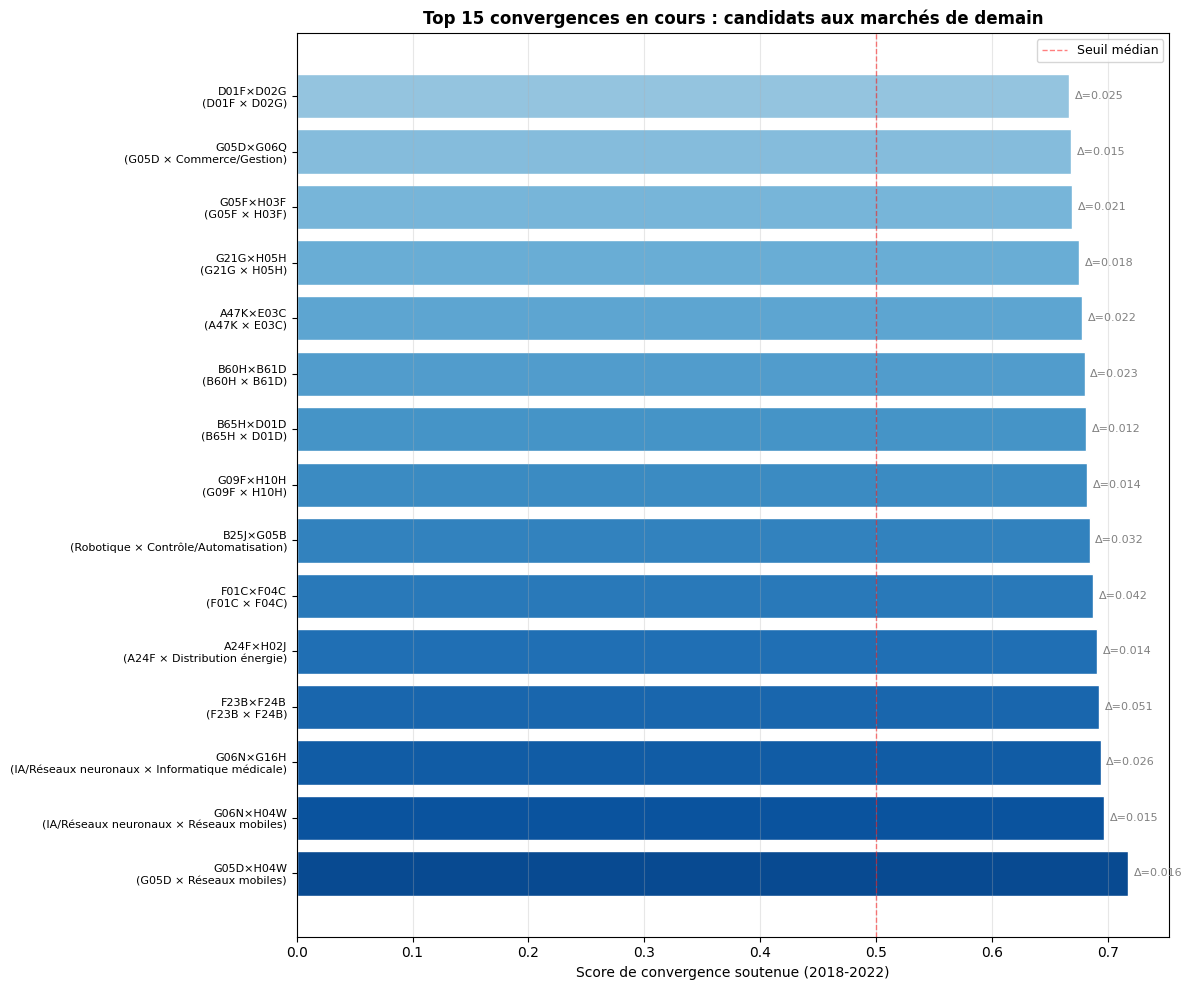

In [12]:
# Visualisation : graphique à barres horizontales
fig, ax = plt.subplots(figsize=(12, 10))

top15 = top_futur.head(15)
labels = [f"{r['cpc_i']}×{r['cpc_j']}\n({CPC_LABELS.get(r['cpc_i'],r['cpc_i'])} × {CPC_LABELS.get(r['cpc_j'],r['cpc_j'])})"
          for _, r in top15.iterrows()]

colors = cm.Blues(np.linspace(0.4, 0.9, len(top15)))
bars = ax.barh(range(len(top15)), top15["score_futur"], color=colors[::-1], edgecolor="white")

# annotations
for i, (bar, (_, row)) in enumerate(zip(bars, top15.iterrows())):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"Δ={row['delta_last']:.3f}",
            va="center", fontsize=8, color="gray")

ax.set_yticks(range(len(top15)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("Score de convergence soutenue (2018-2022)", fontsize=10)
ax.set_title("Top 15 convergences en cours : candidats aux marchés de demain",
             fontsize=12, fontweight="bold")
ax.axvline(0.5, color="red", ls="--", lw=1, alpha=0.5, label="Seuil médian")
ax.legend(fontsize=9)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("top_convergences_futures.png", dpi=150, bbox_inches="tight")
plt.show()

## Analyse 3 — Technologies pivot : les codes au cœur de l'innovation émergente

In [13]:
# Un code CPC est dit "pivot" s'il apparaît dans de nombreuses
# convergences actives simultanément.
# Intuition : c'est la technologie habilitante (enabling technology)
# qui permet à plusieurs domaines de converger.
# Exemple historique : G06F (informatique générale) était pivot
# dans les années 2010 pour l'IA, les télécoms, la robotique, etc.

SEUIL_CI = 0.70  # on ne compte que les convergences fortes

# Paires récentes avec CI élevé
active = panel[(panel["year"]>=2018) & (panel["CI_v6"]>=SEUIL_CI)].copy()

# Comptage par code
from collections import Counter
pivot_count = Counter()
jaccard_sum = defaultdict(float)
for _,row in active.iterrows():
    pivot_count[row["cpc_i"]] += 1
    pivot_count[row["cpc_j"]] += 1
    jaccard_sum[row["cpc_i"]] += row["jaccard"]
    jaccard_sum[row["cpc_j"]] += row["jaccard"]

pivot_df = pd.DataFrame([
    {"cpc4": k, "n_convergences": v,
     "jaccard_cumul": jaccard_sum[k],
     "label": CPC_LABELS.get(k, k)}
    for k,v in pivot_count.items()
]).sort_values("n_convergences", ascending=False).head(25).reset_index(drop=True)

print("TOP 25 TECHNOLOGIES PIVOT (codes impliqués dans le plus de convergences actives 2018-2022)")
print(f"Seuil CI_v6 ≥ {SEUIL_CI}")
display(pivot_df)

TOP 25 TECHNOLOGIES PIVOT (codes impliqués dans le plus de convergences actives 2018-2022)
Seuil CI_v6 ≥ 0.7


,cpc4,n_convergences,jaccard_cumul,label
0,B32B,130,6.273898,B32B
1,G02B,92,3.601312,G02B
2,G05D,92,4.220183,G05D
3,Y02T,90,6.058308,Y02T
4,C09D,85,5.505537,C09D
5,C08L,76,3.180988,C08L
6,H05K,76,2.600995,H05K
7,C08J,76,3.961766,C08J
8,G05B,75,2.599438,Contrôle/Automatisation
9,G06V,75,2.993143,G06V


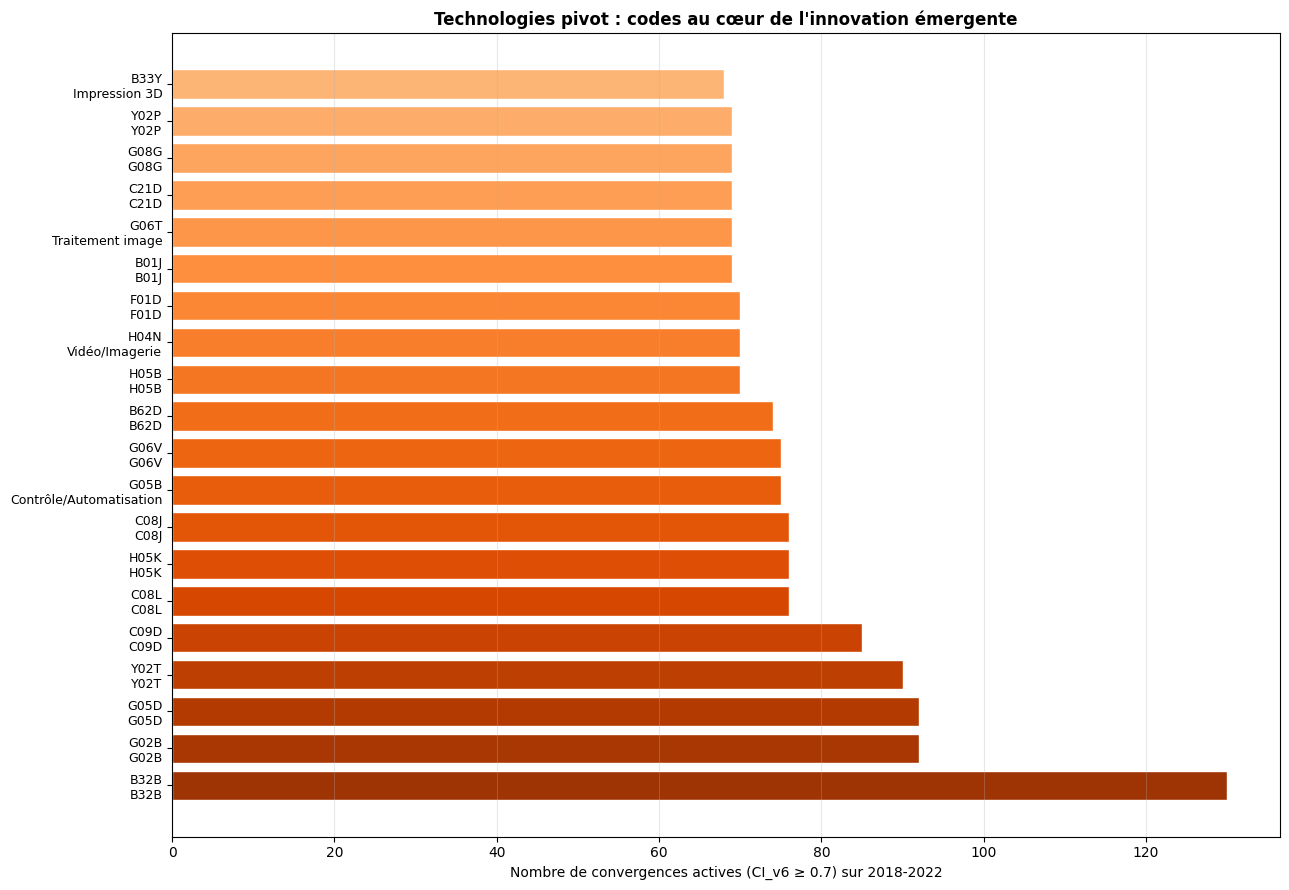

In [14]:
# Graphique technologies pivot
fig, ax = plt.subplots(figsize=(13, 9))
top_pivot = pivot_df.head(20)
labels_p = [f"{r['cpc4']}\n{r['label']}" for _,r in top_pivot.iterrows()]
colors_p = cm.Oranges(np.linspace(0.35, 0.9, len(top_pivot)))
ax.barh(range(len(top_pivot)), top_pivot["n_convergences"], color=colors_p[::-1], edgecolor="white")
ax.set_yticks(range(len(top_pivot)))
ax.set_yticklabels(labels_p, fontsize=9)
ax.set_xlabel(f"Nombre de convergences actives (CI_v6 ≥ {SEUIL_CI}) sur 2018-2022", fontsize=10)
ax.set_title("Technologies pivot : codes au cœur de l'innovation émergente",
             fontsize=12, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("technologies_pivot.png", dpi=150, bbox_inches="tight")
plt.show()

## Analyse 4 — Réseau des convergences actives : cartographie de l'innovation émergente

Réseau : 394 nœuds, 859 arêtes


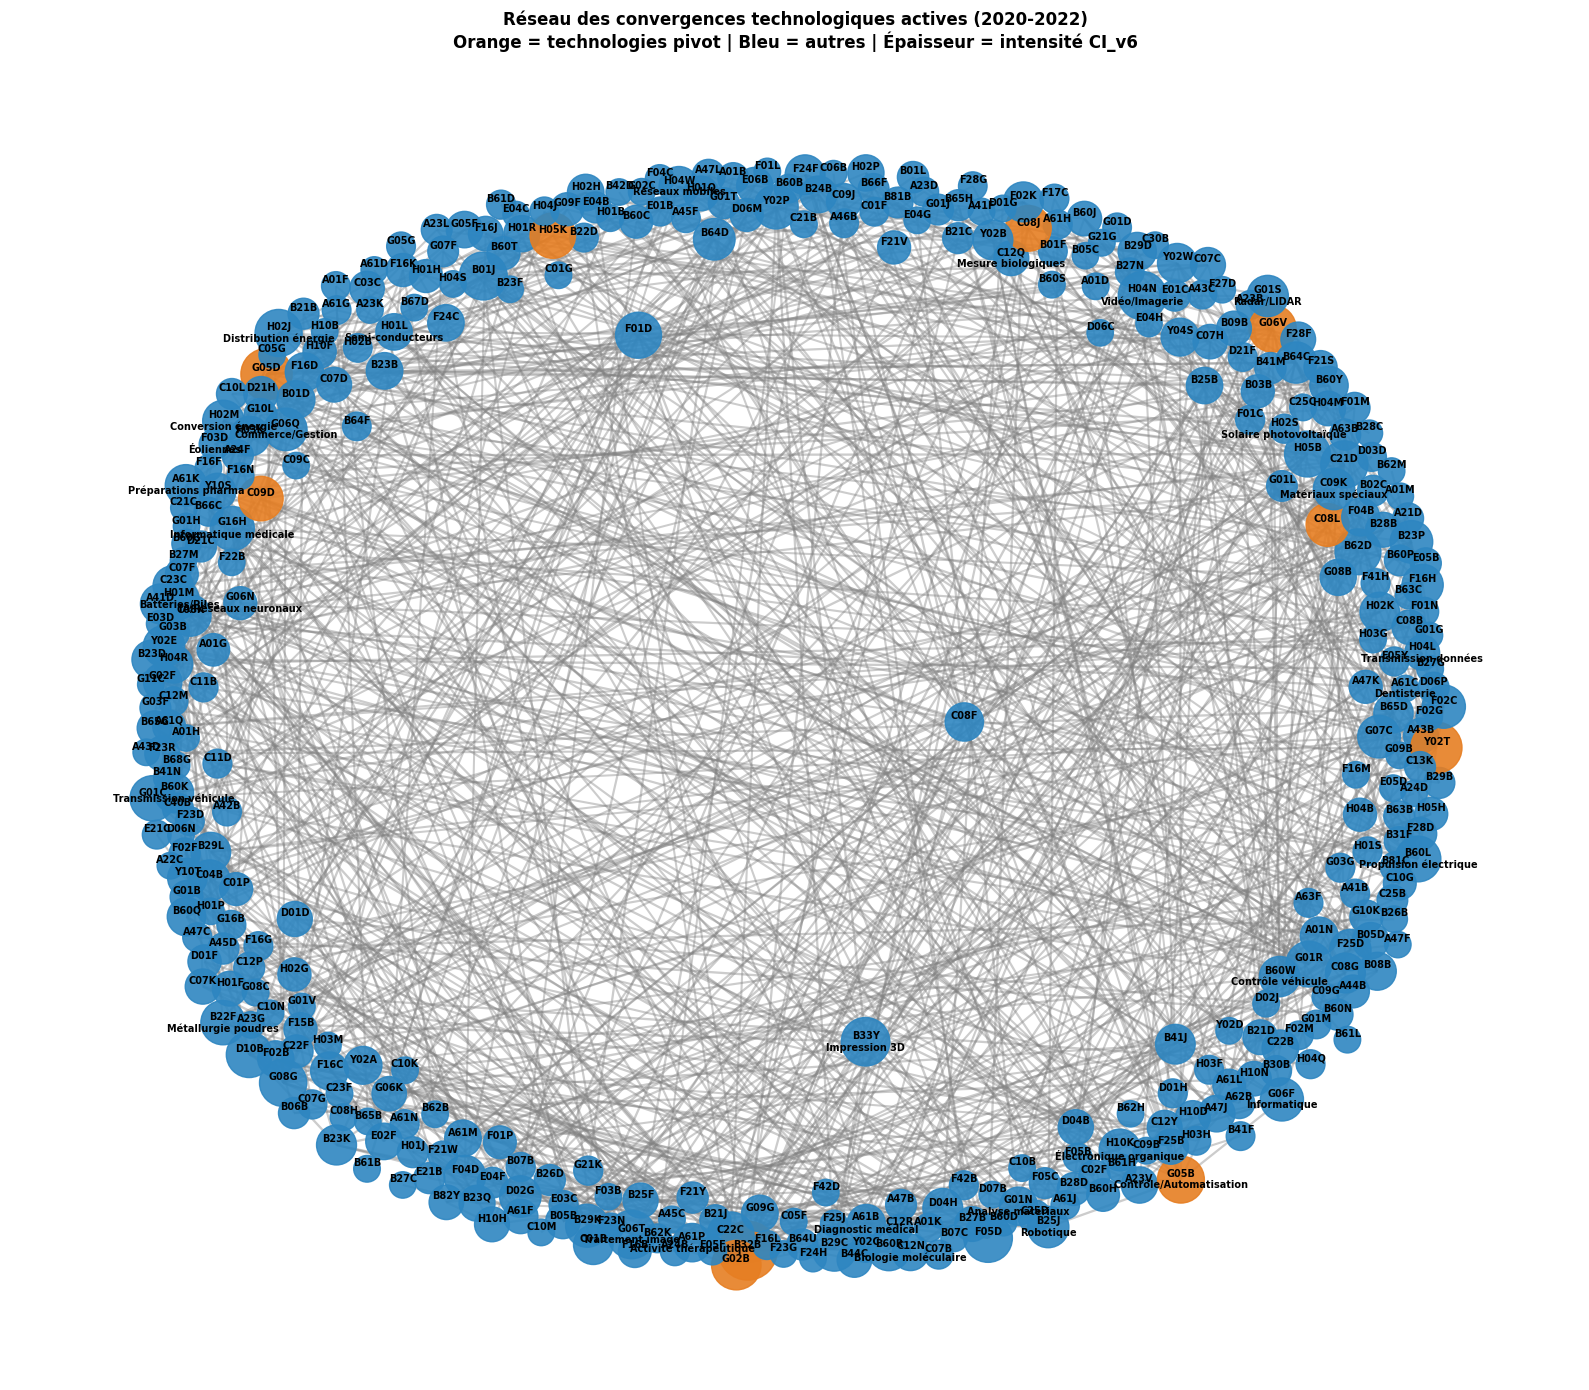

In [15]:
# Construction du réseau des convergences les plus actives (2020-2022)
# Chaque nœud = code CPC, chaque arête = convergence active
# Le poids de l'arête = CI_v6 médian sur 2020-2022

net_data = (
    panel[panel["year"] >= 2020]
    .groupby(["cpc_i","cpc_j"])["CI_v6"]
    .median().reset_index()
)
net_data = net_data[net_data["CI_v6"] >= 0.72].copy()

G = nx.Graph()
for _, row in net_data.iterrows():
    G.add_edge(row["cpc_i"], row["cpc_j"], weight=row["CI_v6"])

# Garder seulement les composantes connexes avec ≥ 3 nœuds
components = [c for c in nx.connected_components(G) if len(c) >= 3]
nodes_keep = set().union(*components)
G = G.subgraph(nodes_keep).copy()

print(f"Réseau : {G.number_of_nodes()} nœuds, {G.number_of_edges()} arêtes")

# Layout et visualisation
fig, ax = plt.subplots(figsize=(16, 14))

pos = nx.spring_layout(G, k=2.5, seed=42, weight="weight")

# Degré pondéré pour taille des nœuds
degree_w = dict(G.degree(weight="weight"))
node_sizes = [300 + 1500 * degree_w.get(n, 0) / max(degree_w.values(), default=1)
              for n in G.nodes()]

# Couleur : technologie pivot = orange, autres = bleu
top_pivot_codes = set(pivot_df.head(10)["cpc4"].tolist())
node_colors = ["#E67E22" if n in top_pivot_codes else "#2E86C1" for n in G.nodes()]

# Arêtes
edge_weights = [G[u][v]["weight"] for u,v in G.edges()]
nx.draw_networkx_edges(G, pos, ax=ax,
                       width=[2*w for w in edge_weights],
                       alpha=0.4, edge_color="gray")

# Nœuds
nx.draw_networkx_nodes(G, pos, ax=ax,
                       node_size=node_sizes,
                       node_color=node_colors, alpha=0.9)

# Labels avec signification
labels_net = {n: f"{n}\n{CPC_LABELS.get(n,'')}" for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels_net, ax=ax,
                        font_size=7, font_weight="bold")

ax.set_title("Réseau des convergences technologiques actives (2020-2022)\n"
             "Orange = technologies pivot | Bleu = autres | Épaisseur = intensité CI_v6",
             fontsize=12, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig("reseau_convergences_actives.png", dpi=150, bbox_inches="tight")
plt.show()

## Analyse 5 — MODE B : la tendance macroscopique et ses accélérations

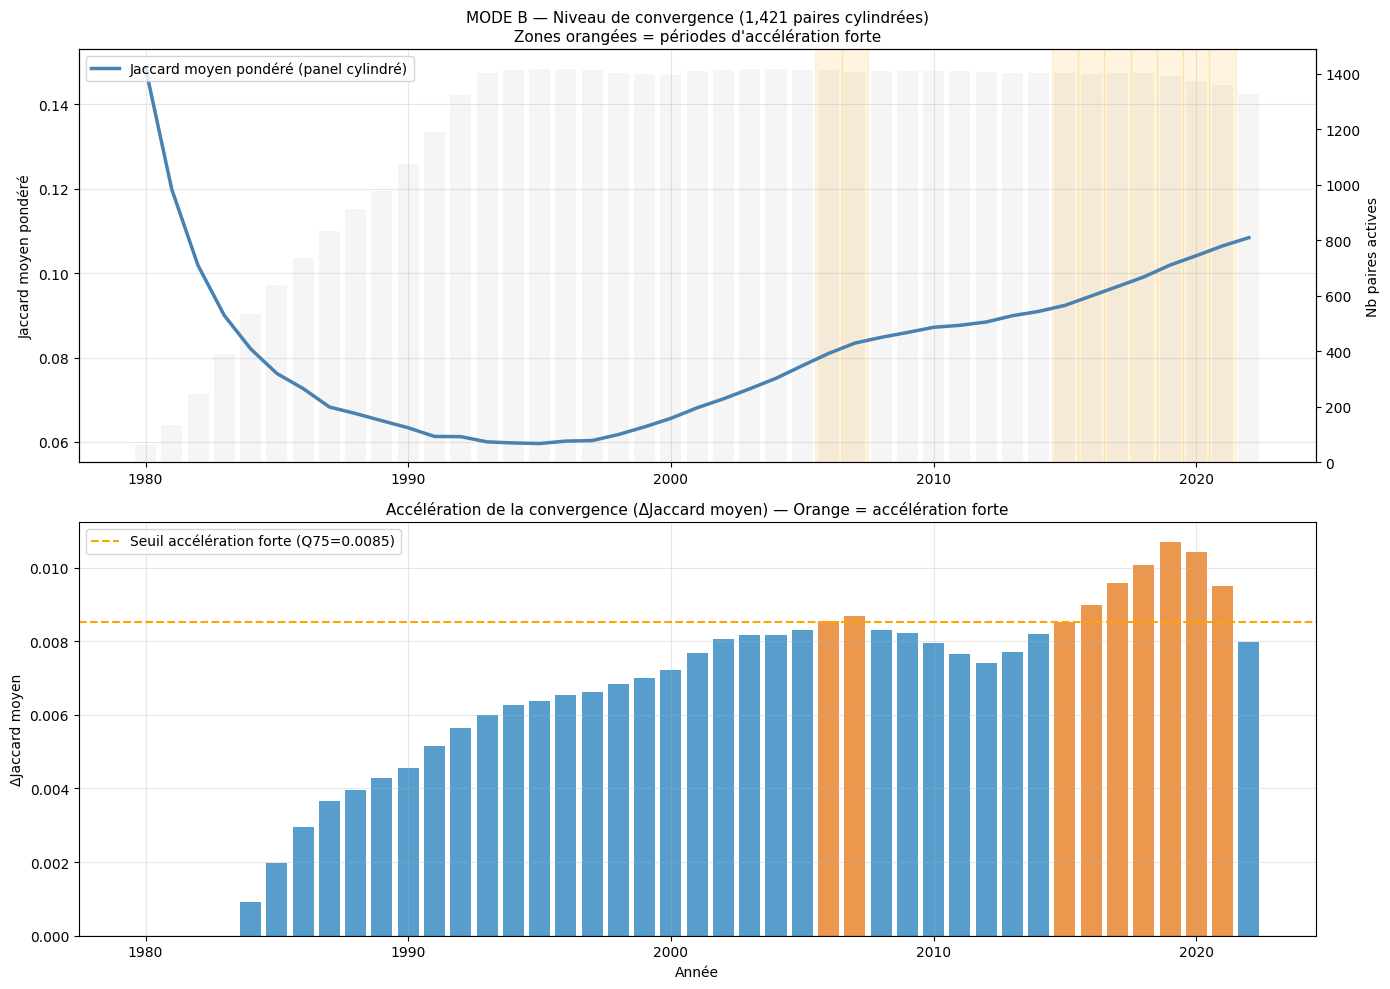


Périodes d'accélération forte détectées :
  2006 : ΔJaccard = 0.00856
  2007 : ΔJaccard = 0.00868
  2015 : ΔJaccard = 0.00852
  2016 : ΔJaccard = 0.00897
  2017 : ΔJaccard = 0.00957
  2018 : ΔJaccard = 0.01008
  2019 : ΔJaccard = 0.01070
  2020 : ΔJaccard = 0.01043
  2021 : ΔJaccard = 0.00949


In [16]:
# Panel cylindré : paires présentes sur ≥ MIN_YEARS_CYLINDRE années
years_pp = panel.groupby(["cpc_i","cpc_j"])["year"].nunique().reset_index(name="n_years")
stable   = years_pp[years_pp["n_years"]>=MIN_YEARS_CYLINDRE][["cpc_i","cpc_j"]]
panel_B  = panel.merge(stable,on=["cpc_i","cpc_j"],how="inner")

CI_B = (
    panel_B.groupby("year")
    .apply(lambda g: pd.Series({
        "jaccard_moy" : np.average(g["jaccard"],    weights=g["n_cooc"]),
        "delta_moy"   : np.average(g["delta_jaccard"], weights=g["n_cooc"]),
        "n_paires"    : len(g)
    }))
    .reset_index()
)

# Détection des périodes d'accélération significative
# (ΔJaccard moyen dans le top 25% des années)
seuil_accel = CI_B[CI_B["year"]>=1990]["delta_moy"].quantile(0.75)
CI_B["accel_forte"] = (CI_B["delta_moy"] >= seuil_accel) & (CI_B["year"] >= 1990)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Graphique 1 : niveau
ax1 = axes[0]; ax1b = ax1.twinx()
ax1.plot(CI_B["year"], CI_B["jaccard_moy"], color="steelblue", lw=2.5,
         label="Jaccard moyen pondéré (panel cylindré)")
# zones d'accélération
for _, row in CI_B[CI_B["accel_forte"]].iterrows():
    ax1.axvspan(row["year"]-0.5, row["year"]+0.5, alpha=0.12, color="orange")
ax1b.bar(CI_B["year"], CI_B["n_paires"], alpha=0.08, color="gray")
ax1.set_title(f"MODE B — Niveau de convergence ({len(stable):,} paires cylindrées)\n"
              "Zones orangées = périodes d'accélération forte", fontsize=11)
ax1.set_ylabel("Jaccard moyen pondéré")
ax1b.set_ylabel("Nb paires actives")
ax1.legend(loc="upper left")
ax1.grid(alpha=0.3)

# Graphique 2 : accélération
ax2 = axes[1]
colors_b = ["#E67E22" if v else "#2E86C1" for v in CI_B["accel_forte"]]
ax2.bar(CI_B["year"], CI_B["delta_moy"], color=colors_b, alpha=0.8)
ax2.axhline(0, color="black", lw=0.8)
ax2.axhline(seuil_accel, color="orange", ls="--", lw=1.5,
            label=f"Seuil accélération forte (Q75={seuil_accel:.4f})")
ax2.set_title("Accélération de la convergence (ΔJaccard moyen) — Orange = accélération forte",
              fontsize=11)
ax2.set_xlabel("Année")
ax2.set_ylabel("ΔJaccard moyen")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("mode_B_v6.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nPériodes d'accélération forte détectées :")
for _, row in CI_B[CI_B["accel_forte"]].iterrows():
    print(f"  {int(row['year'])} : ΔJaccard = {row['delta_moy']:.5f}")

## Export final

In [17]:
# Panel complet v6
cols = ["cpc_i","cpc_j","year","C1_A","C3_A","C4_A","CI_v6",
        "jaccard","delta_jaccard","delta_smooth","p_j_given_i","p_i_given_j","n_cooc"]
panel[cols].to_parquet("indice_convergence_v6.parquet", index=False)

# Scores futurs
score_recent.to_parquet("scores_convergence_future.parquet", index=False)

# Série temporelle MODE B
CI_B.to_csv("serie_mode_B_v6.csv", index=False)

# Technologies pivot
pivot_df.to_csv("technologies_pivot.csv", index=False)

print("Fichiers exportés :")
print(f"  indice_convergence_v6.parquet        — {len(panel):,} lignes")
print(f"  scores_convergence_future.parquet    — {len(score_recent):,} paires scorées")
print(f"  serie_mode_B_v6.csv                  — {len(CI_B)} années")
print(f"  technologies_pivot.csv               — {len(pivot_df)} codes pivot")

print("\n" + "═"*60)
print("RÉSUMÉ : CE QUE L'INDICE NOUS DIT")
print("═"*60)
print(f"""\n
MODE A (classement) :
  → Identifie les {int((panel['CI_v6']>=0.70).sum()/panel['year'].nunique())} paires/an
     en convergence forte (CI_v6 ≥ 0.70)
  → Top convergences 2020-2022 = candidats aux marchés 2025-2030

MODE B (tendance) :
  → Jaccard moyen sur panel cylindré : {CI_B[CI_B['year']==1997]['jaccard_moy'].values[0]:.3f} (1997)
     → {CI_B[CI_B['year']==2022]['jaccard_moy'].values[0]:.3f} (2022)
  → Multiplication par {CI_B[CI_B['year']==2022]['jaccard_moy'].values[0]/CI_B[CI_B['year']==1997]['jaccard_moy'].values[0]:.1f}x en 25 ans
  → Accélération détectée dans {CI_B['accel_forte'].sum()} années

Technologies pivot (2018-2022) :
  → Le code le plus pivot est {pivot_df.iloc[0]['cpc4']} ({pivot_df.iloc[0]['label']})
     impliqué dans {pivot_df.iloc[0]['n_convergences']} convergences actives
""")

Fichiers exportés :
  indice_convergence_v6.parquet        — 145,843 lignes
  scores_convergence_future.parquet    — 10,043 paires scorées
  serie_mode_B_v6.csv                  — 43 années
  technologies_pivot.csv               — 25 codes pivot

════════════════════════════════════════════════════════════
RÉSUMÉ : CE QUE L'INDICE NOUS DIT
════════════════════════════════════════════════════════════


MODE A (classement) :
  → Identifie les 363 paires/an
     en convergence forte (CI_v6 ≥ 0.70)
  → Top convergences 2020-2022 = candidats aux marchés 2025-2030

MODE B (tendance) :
  → Jaccard moyen sur panel cylindré : 0.060 (1997)
     → 0.108 (2022)
  → Multiplication par 1.8x en 25 ans
  → Accélération détectée dans 9 années

Technologies pivot (2018-2022) :
  → Le code le plus pivot est B32B (B32B)
     impliqué dans 130 convergences actives

